# Multi-Region SIRS Epidemic Model with Gurobi Optimal Control

Compares three strategies:
1. **No control** – baseline
2. **Greedy heuristic** – myopic force-of-infection allocation
3. **Gurobi optimal control** – full-horizon QCP (minimises total infected-days)

*AI Disclaimer: Parts generated via prompt engineering from GPT 5.2 and Claude Sonnet 4.5.*

## 0. Installs & Imports

In [ ]:
# ── Colab setup ──────────────────────────────────────────────────────────────
!pip install gurobipy -q
from google.colab import drive
drive.mount('/content/drive')
import os
os.environ["GRB_LICENSE_FILE"] = "/content/drive/MyDrive/Classes/CLASSES 25-26/SPRING '26/ORF 499/ORF499_Midterm_Report/gurobi.lic"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%matplotlib inline
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB


## 1. Data Loading

In [ ]:
def load_all_data(data_path, adj_path):
    df = pd.read_csv(data_path, parse_dates=['date'])
    daily_cases = df.groupby(['date','state'])['new_cases_7day'].sum().unstack('state').fillna(0)
    pop = df[['state','pop_2020']].drop_duplicates().set_index('state')['pop_2020']
    with open(adj_path) as f: adjacency = json.load(f)
    return daily_cases, pop, adjacency


In [ ]:
# US state areas in km² (Census figures) — used to compute population density
STATE_AREA_KM2 = {
    'Alabama':107,  'Alaska':1,  'Arizona':295,  'Arkansas':138,
    'California':404,  'Colorado':269,  'Connecticut':13,  'Delaware':6,
    'Florida':151,  'Georgia':154,  'Hawaii':28,  'Idaho':216,
    'Illinois':144,  'Indiana':94,  'Iowa':146,  'Kansas':213,
    'Kentucky':104,  'Louisiana':112,  'Maine':86,  'Maryland':26,
    'Massachusetts':27,  'Michigan':151,  'Minnesota':225,  'Mississippi':121,
    'Missouri':180,  'Montana':381,  'Nebraska':200,  'Nevada':286,
    'New Hampshire':24,  'New Jersey':20,  'New Mexico':315,  'New York':128,
    'North Carolina':136,  'North Dakota':183,  'Ohio':106,  'Oklahoma':181,
    'Oregon':255,  'Pennsylvania':119,  'Rhode Island':4,  'South Carolina':80,
    'South Dakota':199,  'Tennessee':109,  'Texas':696,  'Utah':220,
    'Vermont':25,  'Virginia':105,  'Washington':185,  'West Virginia':62,
    'Wisconsin':145,  'Wyoming':253,
}
# Areas are in units of 1000 km² to keep density values human-readable
STATE_AREA_KM2 = {k: v * 1000 for k, v in STATE_AREA_KM2.items()}


def compute_density_self_weights(
    states, pop_arr,
    w_min=0.5, w_max=0.9,
    area_km2=None,
):
    """
    Compute per-state self-weights scaled by log population density.

    Denser states (more cities, higher contact rates) get a self-weight
    closer to w_max; sparse rural states get one closer to w_min.

    Parameters
    ----------
    states   : list[str]  -- state names
    pop_arr  : (n,)       -- population per state
    w_min    : float      -- minimum self-weight (sparsest state)
    w_max    : float      -- maximum self-weight (densest state)
    area_km2 : dict       -- state -> area in km²; defaults to STATE_AREA_KM2

    Returns
    -------
    self_weights : (n,) array of per-state self-weights
    densities    : (n,) array of population densities (people/km²)
    """
    if area_km2 is None:
        area_km2 = STATE_AREA_KM2

    densities = np.array([
        pop_arr[i] / area_km2.get(s, 200_000)  # fallback: median-ish area
        for i, s in enumerate(states)
    ])

    # Log-scale normalisation (density spans orders of magnitude)
    log_d     = np.log1p(densities)
    log_d_min = log_d.min()
    log_d_max = log_d.max()

    if log_d_max == log_d_min:  # all states identical — shouldn't happen
        t = np.full(len(states), 0.5)
    else:
        t = (log_d - log_d_min) / (log_d_max - log_d_min)  # in [0, 1]

    self_weights = w_min + (w_max - w_min) * t
    return self_weights, densities


def build_weight_matrix(
    states, adjacency, pop_arr=None,
    self_weight=0.7,          # used only if pop_arr is None
    w_min=0.5, w_max=0.9,     # density-scaling range
):
    """
    Build the inter-state contact weight matrix W.

    If pop_arr is provided, self-weights W[i,i] are scaled by log population
    density: denser states have higher self-weight (more intra-state spread).
    Otherwise, a fixed self_weight is used for all states.

    The remaining weight (1 - W[i,i]) is split evenly across neighbours.
    Each row sums to 1.
    """
    n   = len(states)
    W   = np.zeros((n, n))
    idx = {s: i for i, s in enumerate(states)}

    if pop_arr is not None:
        self_weights, densities = compute_density_self_weights(
            states, pop_arr, w_min=w_min, w_max=w_max
        )
        print('Population density self-weights (sample):')
        order = np.argsort(densities)[::-1]
        for rank in list(order[:3]) + list(order[-3:]):
            print(f'  {states[rank]:20s}  density={densities[rank]:6.1f}/km²  '
                  f'self_weight={self_weights[rank]:.3f}')
    else:
        self_weights = np.full(n, self_weight)

    for s in states:
        i  = idx[s]
        sw = self_weights[i]
        nb = [x for x in adjacency.get(s, []) if x in idx]
        if not nb:
            W[i, i] = 1.0
        else:
            W[i, i] = sw
            for x in nb:
                W[i, idx[x]] = (1 - sw) / len(nb)

    return W, idx


## 3. SIRS Dynamics

In [ ]:
def step_sirs(S, I, R, W, beta, gamma, xi, u, eff=0.8, dt=1.0):
    u = np.clip(u, 0.0, S)
    N = np.maximum(S+I+R, 1.0)
    new_inf  = beta * S * (W @ (I/N)) * dt
    recov    = gamma * I * dt
    loss_imm = xi * R * dt
    return (np.maximum(S - new_inf - eff*u + loss_imm, 0.0),
            np.maximum(I + new_inf - recov, 0.0),
            np.maximum(R + recov + eff*u - loss_imm, 0.0),
            new_inf)

def simulate(S0, I0, R0, W, beta_t, gamma, xi, policy=None):
    T, n = len(beta_t), len(S0)
    Sh,Ih,Rh,uh,ich = (np.zeros((T,n)) for _ in range(5))
    S,I,R = S0.copy(),I0.copy(),R0.copy()
    for t in range(T):
        Sh[t],Ih[t],Rh[t] = S,I,R
        u = policy(t,S,I,R,beta_t[t]) if policy else np.zeros(n)
        uh[t] = u
        S,I,R,ic = step_sirs(S,I,R,W,beta_t[t],gamma,xi,u)
        ich[t] = ic
    return Sh,Ih,Rh,ich,uh


## 4. Piecewise-Constant Beta

In [ ]:
def dates_to_boundaries(dates, bds):
    T = len(dates)
    bs = sorted({int(dates.searchsorted(pd.to_datetime(d))) for d in bds if 0 < int(dates.searchsorted(pd.to_datetime(d))) < T})
    if not bs or bs[-1] != T: bs.append(T)
    return bs

def build_beta_series(betas, boundaries, T):
    betas = np.asarray(betas, float); bt = np.zeros(T); s = 0
    for b,e in zip(betas,boundaries): bt[s:e]=b; s=e
    return bt


In [ ]:
def calibrate_and_plot(
    data_path, adj_path,
    start_date='2020-01-21', end_date='2023-03-23',
    self_weight=0.7,
    gamma=1/5.0, xi=1/180.0,
):
    """
    Validates the SIRS model against observed U.S. COVID-19 case data.

    Steps:
      1. Load data, build W, set initial conditions
      2. Build piecewise-constant beta_t from calibrated regime values
      3. Simulate no-control SIRS forward
      4. Aggregate model incidence nationally and estimate reporting scale kappa
      5. Compute log-MSE loss
      6. Plot model vs data with regime change markers

    Returns
    -------
    kappa   : float  -- reporting scale factor
    log_mse : float  -- log-scale mean squared error
    """
    # ── Load ──────────────────────────────────────────────────────────────
    daily_cases, pop, adjacency = load_all_data(data_path, adj_path)
    cases  = daily_cases.loc[start_date:end_date]
    dates  = cases.index
    states = list(cases.columns)
    n, T   = len(states), len(dates)
    N_pop  = pop.reindex(states).values.astype(float)
    W, _   = build_weight_matrix(states, adjacency, pop_arr=N_pop)

    # ── Initial conditions ────────────────────────────────────────────────
    I0  = np.clip(cases[states].iloc[:21].sum().values * 15.0, 30, 0.05 * N_pop)
    R0_ = np.zeros_like(I0)
    S0  = N_pop - I0 - R0_

    # ── Calibrated beta time series ───────────────────────────────────────
    # Regime boundaries coincide with major epidemiological milestones:
    #   2020-03-20 : widespread lockdowns begin
    #   2021-04-01 : vaccine rollout plateau / Delta emergence
    #   2021-11-20 : Omicron variant emergence
    regime_dates = ['2020-03-20', '2021-04-01', '2021-11-20']
    bdry   = dates_to_boundaries(dates, regime_dates)
    betas  = np.array([0.10230168, 0.25600328, 0.23197981, 0.35418646])
    beta_t = build_beta_series(betas, bdry, T)

    # ── Simulate no-control SIRS ──────────────────────────────────────────
    _, I_hist, _, inc_hist, _ = simulate(S0, I0, R0_, W, beta_t, gamma, xi)

    # ── National aggregation ──────────────────────────────────────────────
    # Model incidence: new infections per day summed across all states
    M = inc_hist.sum(axis=1)              # shape (T,)

    # Observed: national 7-day rolling average new cases
    D = cases[states].sum(axis=1).values  # shape (T,)

    # ── Reporting scale factor kappa (least squares) ──────────────────────
    # kappa minimises sum (D_t - kappa * M_t)^2
    # Closed form: kappa = (D . M) / (M . M)
    kappa = np.dot(D, M) / (np.dot(M, M) + 1e-10)
    M_scaled = kappa * M

    # ── Log-scale MSE (calibration loss from thesis eq. 4.9) ─────────────
    eps = 1.0
    log_mse = np.mean((np.log(M_scaled + eps) - np.log(D + eps)) ** 2)
    print(f'Reporting scale factor kappa : {kappa:.4f}')
    print(f'Log-scale MSE               : {log_mse:.6f}')

    # ── Plot ──────────────────────────────────────────────────────────────
    dates_dt = pd.to_datetime(dates)
    regime_dt = [pd.to_datetime(d) for d in regime_dates]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Panel 1: model vs data
    ax = axes[0]
    ax.plot(dates_dt, D,        color='steelblue', lw=1.5, label='Observed (7-day avg cases)')
    ax.plot(dates_dt, M_scaled, color='darkorange', lw=1.5, ls='--', label=f'Model (scaled, κ={kappa:.2f})')
    for rd in regime_dt:
        ax.axvline(rd, color='gray', ls=':', lw=1.0)
    ax.set_title('COVID-19: Model vs Observed Data (No Vaccine Control)')
    ax.set_ylabel('Daily new cases')
    ax.legend()

    # Add regime labels
    regime_labels = ['Lockdowns', 'Delta/\nVaccine plateau', 'Omicron']
    for rd, lbl in zip(regime_dt, regime_labels):
        ax.text(rd, ax.get_ylim()[1] * 0.92, lbl, fontsize=7,
                color='gray', ha='left', rotation=0)

    # Panel 2: log-scale comparison (reveals relative fit across waves)
    ax = axes[1]
    ax.plot(dates_dt, np.log1p(D),        color='steelblue', lw=1.5, label='log(1 + Observed)')
    ax.plot(dates_dt, np.log1p(M_scaled), color='darkorange', lw=1.5, ls='--', label='log(1 + Model scaled)')
    for rd in regime_dt:
        ax.axvline(rd, color='gray', ls=':', lw=1.0)
    ax.set_title(f'Log-Scale Comparison  (log-MSE = {log_mse:.4f})')
    ax.set_ylabel('log(1 + daily cases)')
    ax.set_xlabel('Date')
    ax.legend()

    xt = np.linspace(0, len(dates_dt)-1, 10, dtype=int)
    for ax in axes:
        ax.set_xticks(dates_dt[xt])
        ax.set_xticklabels([dates_dt[i].strftime('%Y-%m-%d') for i in xt],
                           rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    return kappa, log_mse


Population density self-weights (sample):
  Alaska                density= 733.0/km²  self_weight=0.900
  New Jersey            density= 463.6/km²  self_weight=0.866
  Connecticut           density= 275.2/km²  self_weight=0.828
  North Dakota          density=   4.3/km²  self_weight=0.535
  Montana               density=   2.9/km²  self_weight=0.512
  Wyoming               density=   2.3/km²  self_weight=0.500
Reporting scale factor kappa : 0.1170
Log-scale MSE               : 11.102170


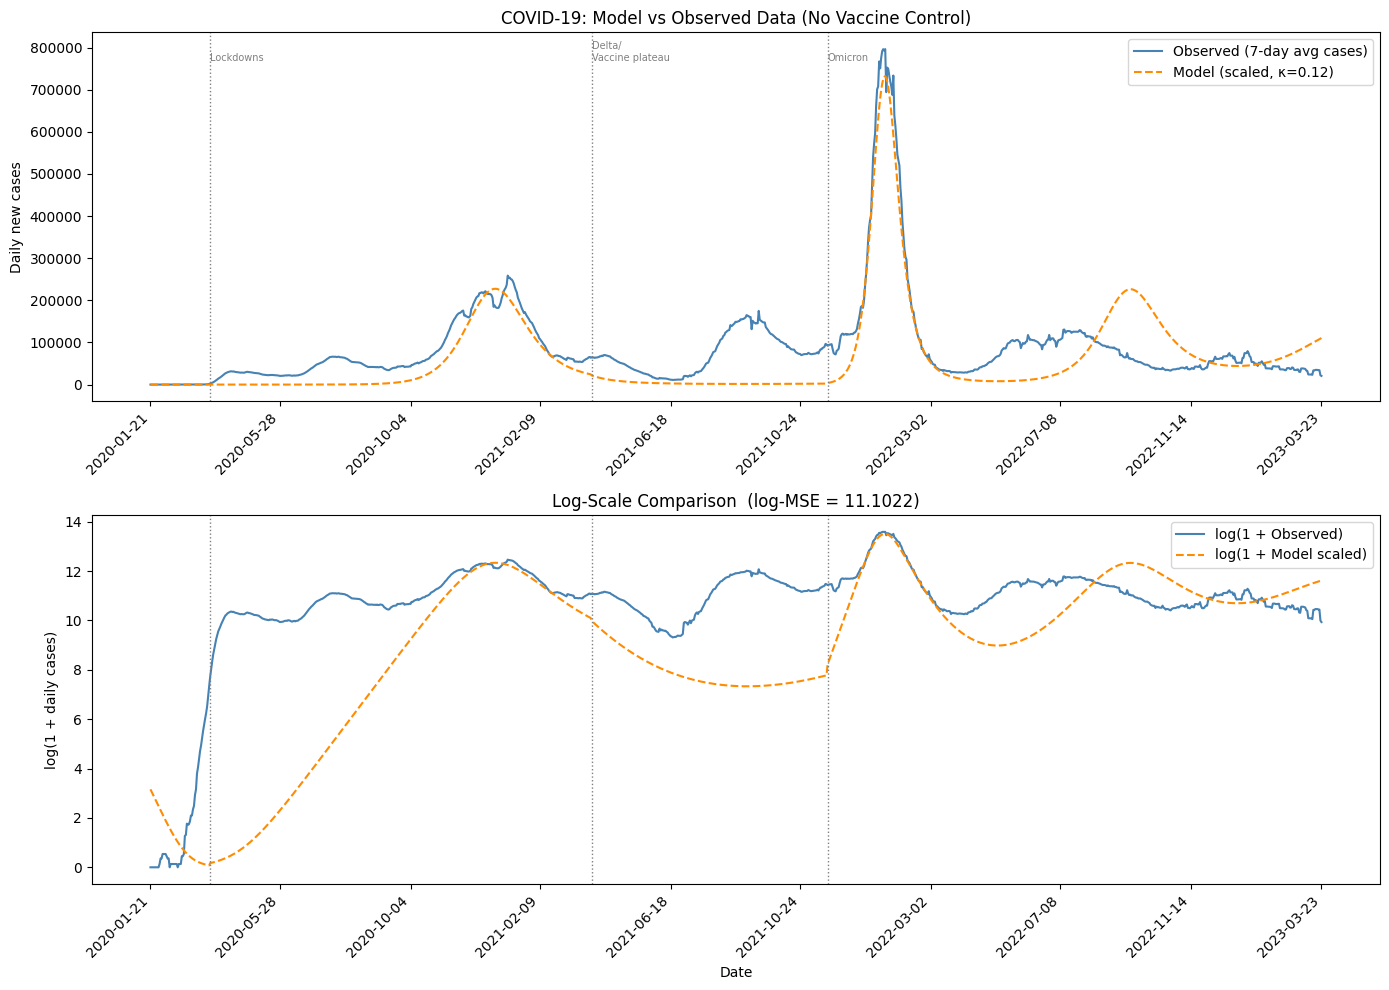

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Classes/CLASSES 25-26/FALL '25/ORF 498/ORF498_Final_Report/processed_covid_state_data.csv"
ADJ_PATH  = "/content/drive/MyDrive/Classes/CLASSES 25-26/FALL '25/ORF 498/ORF498_Final_Report/state_adjacency.json"

kappa, log_mse = calibrate_and_plot(DATA_PATH, ADJ_PATH)


In [ ]:
def make_greedy_policy(W, supply, budget, cost, cap=None):
    spent = {'v':0.0}
    def pol(t,S,I,R,beta):
        left = budget - spent['v']
        if left<=0: return np.zeros_like(S)
        U = min(supply, left/cost)
        N = np.maximum(S+I+R,1.0)
        score = beta*(W@(I/N))
        c = np.minimum(S,cap) if cap is not None else S.copy()
        order = np.argsort(-score); u=np.zeros_like(S); rem=U
        for i in order:
            if rem<=0: break
            take=min(c[i],rem); u[i]=take; rem-=take
        spent['v'] += cost*u.sum()
        return u
    return pol

def make_ramped_policy(base, dates, vax_start, ramp_days=90):
    i0 = dates.searchsorted(pd.Timestamp(vax_start))
    def pol(t,S,I,R,beta):
        if t<i0: return np.zeros_like(S)
        return min(1.0,(t-i0+1)/ramp_days)*base(t,S,I,R,beta)
    return pol


In [ ]:
def solve_gurobi(T, n, W, N_pop, beta_t, gamma, xi,
                 U_daily, budget, cost, u_bar, S0, I0, R0,
                 eff=0.8, time_limit=300, verbose=False):
    """
    Gurobi QCP for epidemic vaccination control.

    min  sum_{t,i} I_{t,i}
    s.t. lam_{t,i}  = sum_j W_{ij}*I_{t,j}/N_j          (linear)
         z_{t,i}    = S_{t,i} * lam_{t,i}                (bilinear QC)
         S_{t+1,i}  = S_t - beta*z - eff*u + xi*R        (linear)
         I_{t+1,i}  = I_t + beta*z - gamma*I             (linear)
         R_{t+1,i}  = R_t + gamma*I + eff*u - xi*R       (linear)
         0 <= u_{t,i} <= min(S_{t,i}, u_bar_i)           (box)
         sum_i u_{t,i} <= U                              (capacity)
         cost * sum u <= budget                          (budget)
    """
    m = gp.Model('EpiControl')
    m.setParam('OutputFlag', int(verbose))
    m.setParam('NonConvex', 2)   # required for bilinear QCP
    m.setParam('TimeLimit', time_limit)

    u   = m.addVars(T,   n, lb=0.0, name='u')
    S   = m.addVars(T+1, n, lb=0.0, name='S')
    I   = m.addVars(T+1, n, lb=0.0, name='I')
    R   = m.addVars(T+1, n, lb=0.0, name='R')
    lam = m.addVars(T,   n, lb=0.0, name='lam')
    z   = m.addVars(T,   n, lb=0.0, name='z')

    m.setObjective(gp.quicksum(I[t,i] for t in range(T) for i in range(n)), GRB.MINIMIZE)

    for i in range(n):
        m.addConstr(S[0,i]==S0[i]); m.addConstr(I[0,i]==I0[i]); m.addConstr(R[0,i]==R0[i])

    for t in range(T):
        for i in range(n):
            # lambda definition
            m.addConstr(lam[t,i] == gp.quicksum(W[i,j]*I[t,j]/N_pop[j] for j in range(n)))
            # bilinear auxiliary
            m.addQConstr(z[t,i] == S[t,i]*lam[t,i])
            # SIRS transitions
            m.addConstr(S[t+1,i] == S[t,i] - beta_t[t]*z[t,i] - eff*u[t,i] + xi*R[t,i])
            m.addConstr(I[t+1,i] == I[t,i] + beta_t[t]*z[t,i] - gamma*I[t,i])
            m.addConstr(R[t+1,i] == R[t,i] + gamma*I[t,i] + eff*u[t,i] - xi*R[t,i])
            # box constraints
            m.addConstr(u[t,i] <= S[t,i])   # can't vaccinate more than susceptible pool
            m.addConstr(u[t,i] <= u_bar[i]) # per-region cap
        # per-step total capacity
        m.addConstr(gp.quicksum(u[t,i] for i in range(n)) <= U_daily)
    # global budget
    m.addConstr(cost*gp.quicksum(u[t,i] for t in range(T) for i in range(n)) <= budget)

    m.optimize()

    STAT = {GRB.OPTIMAL:'OPTIMAL', GRB.INFEASIBLE:'INFEASIBLE',
            GRB.TIME_LIMIT:'TIME_LIMIT (best incumbent)', GRB.UNBOUNDED:'UNBOUNDED'}
    res = {'status': STAT.get(m.Status, f'CODE_{m.Status}')}
    if m.SolCount > 0:
        res['obj'] = m.ObjVal
        res['u'] = np.array([[u[t,i].X for i in range(n)] for t in range(T)])
        res['I'] = np.array([[I[t,i].X for i in range(n)] for t in range(T+1)])
        res['S'] = np.array([[S[t,i].X for i in range(n)] for t in range(T+1)])
        res['R'] = np.array([[R[t,i].X for i in range(n)] for t in range(T+1)])
    return res

def make_gurobi_policy(u_opt, T_opt, vax_idx):
    def pol(t,S,I,R,beta):
        lt = t - vax_idx
        if lt<0 or lt>=T_opt: return np.zeros(u_opt.shape[1])
        return u_opt[lt]
    return pol


In [ ]:
def make_rolling_horizon_policy(
    W, N_pop, beta_t, gamma, xi,
    U_daily, total_budget, cost_per_dose, u_bar,
    vax_start_idx,
    T_opt=30, step=7,
    time_limit=60, verbose=False,
):
    """
    Rolling horizon (MPC) vaccine allocation policy.

    At each re-plan step, solves a Gurobi QCP over the next T_opt days.

    Fallback hierarchy when Gurobi fails:
      1. TIME_LIMIT with incumbent  -> use best incumbent found (don't waste it)
      2. INFEASIBLE / no incumbent  -> fall back to greedy for that step
    """
    n     = len(N_pop)
    spent = {'v': 0.0}
    last_plan = {'u': None, 'plan_start': -1}

    # ── Greedy fallback (used when Gurobi finds no feasible solution) ─────
    def greedy_fallback(S, I, R, beta):
        remaining_budget = total_budget - spent['v']
        if remaining_budget <= 0:
            return np.zeros(n)
        U     = min(U_daily, remaining_budget / cost_per_dose)
        N     = np.maximum(S + I + R, 1.0)
        score = beta * (W @ (I / N))
        cap   = np.minimum(S, u_bar)
        order = np.argsort(-score)
        u = np.zeros(n); rem = U
        for i in order:
            if rem <= 0: break
            take = min(cap[i], rem)
            u[i] = take; rem -= take
        return u

    def policy(t, S, I, R, beta):
        # Before vaccine rollout: no doses
        if t < vax_start_idx:
            return np.zeros(n)

        # Budget exhausted
        if spent['v'] >= total_budget:
            return np.zeros(n)

        # Re-solve every `step` days
        need_replan = (
            last_plan['u'] is None or
            (t - last_plan['plan_start']) >= step
        )

        if need_replan:
            T_remaining = len(beta_t) - t
            if T_remaining <= 0:
                return np.zeros(n)

            T_window         = min(T_opt, T_remaining)
            remaining_budget = total_budget - spent['v']

            if verbose:
                print(f'  [MPC] t={t}: solving {T_window}-day window, '
                      f'budget remaining=${remaining_budget:,.0f}')

            # Clip states to be non-negative before passing to Gurobi
            # (floating point drift in the simulator can push values slightly negative)
            S0_g = np.maximum(S, 0.0)
            I0_g = np.maximum(I, 0.0)
            R0_g = np.maximum(R, 0.0)
            # Re-normalise so S+I+R = N exactly
            total = S0_g + I0_g + R0_g
            scale = N_pop / np.maximum(total, 1.0)
            S0_g *= scale; I0_g *= scale; R0_g *= scale

            gres = solve_gurobi(
                T=T_window, n=n, W=W, N_pop=N_pop,
                beta_t=beta_t[t: t + T_window],
                gamma=gamma, xi=xi,
                U_daily=U_daily,
                budget=remaining_budget,
                cost=cost_per_dose,
                u_bar=u_bar,
                S0=S0_g, I0=I0_g, R0=R0_g,
                time_limit=time_limit,
                verbose=False,
            )

            if 'u' in gres:
                # Use whatever Gurobi found — optimal or best incumbent
                if verbose and 'TIME_LIMIT' in gres['status']:
                    print(f'  [MPC] t={t}: TIME_LIMIT — using best incumbent')
                last_plan['u']          = gres['u']
                last_plan['plan_start'] = t
            else:
                # Gurobi found nothing — use greedy for this step
                if verbose:
                    print(f'  [MPC] t={t}: {gres["status"]} — falling back to greedy')
                u_t = greedy_fallback(S, I, R, beta)
                spent['v'] += cost_per_dose * u_t.sum()
                return u_t

        # Index into current plan
        local_t = t - last_plan['plan_start']
        if local_t >= len(last_plan['u']):
            return np.zeros(n)

        u_t = last_plan['u'][local_t].copy()

        # Clip to remaining budget
        max_doses = (total_budget - spent['v']) / cost_per_dose
        u_t = np.clip(u_t, 0, None)
        if u_t.sum() > max_doses:
            u_t = u_t * (max_doses / u_t.sum())

        spent['v'] += cost_per_dose * u_t.sum()
        return u_t

    return policy


## 7. Visualisation

In [ ]:
def plot_comparison(dates, states, I_noc, I_g, I_mpc, u_g, u_mpc, top_k=15, suffix=''):
    """
    Three-panel figure:
      (1) Total infections: no-control vs greedy vs rolling-horizon Gurobi
      (2) Greedy allocation heatmap (top_k states)
      (3) Rolling-horizon Gurobi allocation heatmap (top_k states)
    """
    dates = pd.to_datetime(dates)

    def top_heat(u):
        k = min(top_k, u.shape[1])
        idx = np.argsort(-u.sum(0))[:k]
        return u[:, idx].T, [states[i] for i in idx], k

    hg, lg, k = top_heat(u_g)
    hm, lm, _ = top_heat(u_mpc)

    fig, axes = plt.subplots(3, 1, figsize=(14, 14))

    # Panel 1: infections over time
    ax = axes[0]
    ax.plot(dates, I_noc.sum(1), color='firebrick', lw=2,          label='No control')
    ax.plot(dates, I_g.sum(1),   color='steelblue', lw=2, ls='--', label='Greedy')
    ax.plot(dates, I_mpc.sum(1), color='seagreen',  lw=2, ls='-.', label='Gurobi MPC')
    ax.set_title(f'Total infections over time{suffix}')
    ax.set_ylabel('Infected')
    ax.legend()

    # Panels 2 & 3: allocation heatmaps
    for ax, heat, lbl, cmap, ttl in [
        (axes[1], hg, lg, 'viridis', f'Greedy allocation (top {k} states)'),
        (axes[2], hm, lm, 'magma',   f'Gurobi MPC allocation (top {k} states)'),
    ]:
        ax.imshow(heat, aspect='auto', interpolation='nearest', cmap=cmap)
        ax.set_yticks(np.arange(k))
        ax.set_yticklabels(lbl, fontsize=8)
        ax.set_title(ttl)
        ax.set_xlabel('Date')
        # Set a few evenly spaced date ticks on the heatmap x-axis
        xt = np.linspace(0, len(dates)-1, 6, dtype=int)
        ax.set_xticks(xt)
        ax.set_xticklabels([dates[i].strftime('%Y-%m') for i in xt], rotation=30, ha='right')

    plt.tight_layout()
    fig.autofmt_xdate()   # auto-rotate date labels on the line chart
    plt.show()


In [ ]:
def run_experiment(
    data_path, adj_path,
    start_date='2020-01-21', end_date='2023-03-23', self_weight=0.7,
    gamma=1/5.0, xi=1/180.0,
    supply_per_day=1_000_000, cost_per_dose=40.0,
    budget_fraction=0.6, per_state_cap_frac=0.001,
    vax_start='2020-12-14', ramp_days=90,
    T_opt=30, step=7, time_limit=60,
    gurobi_verbose=False, top_k=15,
    subset=None,   # int: restrict to first N states (for size-limited license)
):
    # ── Load ──────────────────────────────────────────────────────────────
    daily_cases, pop, adjacency = load_all_data(data_path, adj_path)
    cases  = daily_cases.loc[start_date:end_date]
    dates  = cases.index
    states = list(cases.columns)
    N_pop  = pop.reindex(states).values.astype(float)
    W, _   = build_weight_matrix(states, adjacency, pop_arr=N_pop,
                              w_min=0.5, w_max=0.9)
    T      = len(dates)

    # ── Optional subset (for testing under size-limited license) ──────────
    if subset is not None:
        states = states[:subset]
        N_pop  = N_pop[:subset]
        W      = W[:subset, :subset]
        W      = W / W.sum(axis=1, keepdims=True)  # re-normalise rows
        print(f'[subset mode] Using {subset} states, T_opt={T_opt}')
    n = len(states)

    # ── Initial conditions ────────────────────────────────────────────────
    I0  = np.clip(cases[states].iloc[:21].sum().values * 15.0, 30, 0.05 * N_pop)
    R0_ = np.zeros_like(I0)
    S0  = N_pop - I0 - R0_

    # ── Beta time series ──────────────────────────────────────────────────
    bdry   = dates_to_boundaries(dates, ['2020-03-20', '2021-04-01', '2021-11-20'])
    beta_t = build_beta_series([0.10230168, 0.25600328, 0.23197981, 0.35418646], bdry, T)

    total_budget  = budget_fraction * cost_per_dose * supply_per_day * T
    per_state_cap = per_state_cap_frac * N_pop
    vax_idx       = int(dates.searchsorted(pd.Timestamp(vax_start)))

    # ── 1. Baseline ───────────────────────────────────────────────────────
    print('Running no-control baseline...')
    _, I_noc, _, _, _ = simulate(S0, I0, R0_, W, beta_t, gamma, xi)

    # ── 2. Greedy heuristic ───────────────────────────────────────────────
    print('Running greedy heuristic...')
    g_pol = make_ramped_policy(
        make_greedy_policy(W, supply_per_day, total_budget, cost_per_dose, per_state_cap),
        dates, vax_start, ramp_days,
    )
    _, I_g, _, _, u_g = simulate(S0, I0, R0_, W, beta_t, gamma, xi, g_pol)

    # ── 3. Gurobi rolling horizon (MPC) ───────────────────────────────────
    n_solves = max(1, (T - vax_idx) // step)
    print(f'Running Gurobi MPC: T_opt={T_opt}d, step={step}d, '
          f'~{n_solves} solves x {time_limit}s limit each...')
    mpc_pol = make_rolling_horizon_policy(
        W=W, N_pop=N_pop, beta_t=beta_t,
        gamma=gamma, xi=xi,
        U_daily=supply_per_day,
        total_budget=total_budget,
        cost_per_dose=cost_per_dose,
        u_bar=per_state_cap,
        vax_start_idx=vax_idx,
        T_opt=T_opt, step=step,
        time_limit=time_limit,
        verbose=True,
    )
    _, I_mpc, _, _, u_mpc = simulate(S0, I0, R0_, W, beta_t, gamma, xi, mpc_pol)
    print('MPC simulation complete.')

    # ── Plot ──────────────────────────────────────────────────────────────
    plot_comparison(
        dates, states, I_noc, I_g, I_mpc, u_g, u_mpc,
        top_k=min(top_k, n),
        suffix=f' (MPC: T_opt={T_opt}d, step={step}d)',
    )

    # ── Summary stats ─────────────────────────────────────────────────────
    base = I_noc.sum()
    print(f'\nTotal infected-days (all states, full horizon):')
    print(f'  No control : {base:>15,.0f}')
    print(f'  Greedy     : {I_g.sum():>15,.0f}  ({100*(1 - I_g.sum()/base):.1f}% reduction)')
    print(f'  Gurobi MPC : {I_mpc.sum():>15,.0f}  ({100*(1 - I_mpc.sum()/base):.1f}% reduction)')

    return I_noc, I_g, u_g, I_mpc, u_mpc


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Classes/CLASSES 25-26/FALL '25/ORF 498/ORF498_Final_Report/processed_covid_state_data.csv"
ADJ_PATH  = "/content/drive/MyDrive/Classes/CLASSES 25-26/FALL '25/ORF 498/ORF498_Final_Report/state_adjacency.json"

run_experiment(
    data_path=DATA_PATH,
    adj_path=ADJ_PATH,
    T_opt=10,       # keep small for size-limited license; use 30 with full license
    step=7,
    time_limit=60,
    top_k=15,
)


Population density self-weights (sample):
  Alaska                density= 733.0/km²  self_weight=0.900
  New Jersey            density= 463.6/km²  self_weight=0.866
  Connecticut           density= 275.2/km²  self_weight=0.828
  North Dakota          density=   4.3/km²  self_weight=0.535
  Montana               density=   2.9/km²  self_weight=0.512
  Wyoming               density=   2.3/km²  self_weight=0.500
Running no-control baseline...
Running greedy heuristic...
Running Gurobi MPC: T_opt=10d, step=7d, ~118 solves x 60s limit each...
  [MPC] t=328: solving 10-day window, budget remaining=$27,792,000,000
  [MPC] t=335: solving 10-day window, budget remaining=$27,699,360,297
  [MPC] t=335: INFEASIBLE — falling back to greedy
  [MPC] t=336: solving 10-day window, budget remaining=$27,686,126,053
  [MPC] t=343: solving 10-day window, budget remaining=$27,593,486,350
  [MPC] t=350: solving 10-day window, budget remaining=$27,500,846,646
  [MPC] t=357: solving 10-day window, budget rema